# Phase 2 — Impact Prediction (Baseline)
### AI-Assisted Equity-Aware Budget Allocation Framework for Panchayats

**What this notebook does:**
1. Loads the Phase 1 output (`final_need_assessment.csv` — 33 GPs, Entropy-weighted Need Score, priority tiers).
2. Builds a **documented synthetic** Panchayat × sector project-impact training table, since no real historical project-outcome data exists yet for Devadurga.
3. Trains three baseline regression models (Random Forest, XGBoost, LightGBM) to predict project impact from need + budget + population features.
4. Evaluates them with MAE, RMSE, WAPE, R² — the exact metrics table from the research document (Section 6.2).
5. Saves a feature-importance chart as an early, non-SHAP preview of explainability (full SHAP work is Phase 4).
6. Ends with a handoff section: what's done, what's synthetic vs real, and what to do next.

**Run this AFTER Phase 1** (notebooks 01–03) — it reads `final_need_assessment.csv` from `Cleaned/`.

---

## ⚠️ About the synthetic data in this notebook

Real Panchayat-level historical project outcomes (what was spent, on what, and what improved) were not available in time to build this phase. The Review 2 action plan explicitly allows this:

> *"If real Panchayat-level data proves hard to source in time, flag this to your guide early and get sign-off on a documented synthetic dataset — this is a normal, defensible choice at this stage."*

So the `synthetic_impact` target here is a **formula-based placeholder** (a function of need score + budget + noise), not a real outcome. It exists so the pipeline — data → features → model → metrics — runs end-to-end and teammates have something real to extend. **Do not present these numbers as findings.** In the paper, this stage should be described as a pipeline validation / proof-of-concept, with real data substituted before Review 3 if at all possible.


## 1. Setup

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XGBoost and LightGBM aren't preinstalled in every Colab image -- install if missing
try:
    import xgboost as xgb
except ImportError:
    !pip install xgboost -q
    import xgboost as xgb

try:
    import lightgbm as lgb
except ImportError:
    !pip install lightgbm -q
    import lightgbm as lgb

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Data_Organized"
CLEAN_DIR = os.path.join(BASE_DIR, "Cleaned")

np.random.seed(42)
print("Setup complete.")


Setup complete.


## 2. Load Phase 1 output

`final_need_assessment.csv` is the file produced at the end of notebook 02 — 33 rows (one per Devadurga GP), with `need_rank`, `need_score_raw`, `need_score_100`, `priority_category`, the 11 Entropy-weighted indicators, and the separate education sub-index (20/33 GPs).

In [ ]:
need_assessment_file = os.path.join(CLEAN_DIR, "final_need_assessment.csv")
need_df = pd.read_csv(need_assessment_file)

print("Loaded:", need_df.shape)
assert need_df.shape[0] == 33, f"Expected 33 GPs, got {need_df.shape[0]}"
assert "need_score_100" in need_df.columns, "need_score_100 column missing -- check Phase 1 output"

display(need_df[["gp_name", "need_rank", "need_score_100", "priority_category"]].head())


Loaded: (33, 18)


,gp_name,need_rank,need_score_100,priority_category
0,Alkod,2,71.491399,Higher Need
1,Amarapur,12,21.187968,Moderate Need
2,Arkera,20,16.707719,Moderate Need
3,B.Ganekal,25,10.948043,Lower Need
4,Bhumanagunda,18,17.309726,Moderate Need


## 3. Build the synthetic project-level training table

**The unit of analysis changes here.** Phase 1 is one row per GP (33 rows). Phase 2 needs one row per *project* — a GP proposing a budget for a specific sector. So this section expands 33 GPs × 5 sectors = **165 synthetic project records**.

### Sector-need proxy — a known simplification
The research document calls for true sector-level scores `N_is` (Need Score restricted to that sector's own indicators — e.g. only the road-related indicators for the roads sector). That per-sector breakdown wasn't built in Phase 1 (`final_candidates` there produced one overall score, not five sector-specific ones).

As a stand-in, this notebook uses the overall `need_score_100` plus small random jitter per sector, so every sector isn't numerically identical for a given GP. **This is flagged, not hidden** — see the `sector_need_score` column and the note printed below. A meaningful next step (see Section 7) is to go back to Phase 1's normalized indicator table and compute a real `N_is` per sector, then swap it in here.

### Columns generated
| Column | Meaning | Status |
|---|---|---|
| `sector_need_score` | Proxy for sector-level need (0-1) | Proxy — see note above |
| `proposed_budget_lakh` | Hypothetical proposed budget (₹ lakh) | Synthetic |
| `historical_expenditure_lakh` | Hypothetical past spend in that sector | Synthetic |
| `population_affected` | Random population count in a realistic range | Synthetic |
| `synthetic_impact` | **Target variable** — formula-based, not observed | Synthetic (placeholder) |


In [ ]:
# ============================================================
# BUILD PROJECT-LEVEL DATA USING REAL SECTOR-LEVEL NEED SCORES
# ============================================================

SECTORS = [
    "education",
    "electricity_infra",
    "health",
    "livelihood",
    "roads_transport",
    "sanitation"
]

# ------------------------------------------------------------
# 1. Load REAL sector-level Need Scores from Notebook 02
# ------------------------------------------------------------

gp_sector_need_scores = pd.read_csv(
    os.path.join(
        CLEAN_DIR,
        "gp_sector_need_scores.csv"
    )
)

print(
    "Real sector Need Score table:",
    gp_sector_need_scores.shape
)

# Check expected columns
required_cols = ["gp_name", "sector", "sector_need_score"]

missing_cols = [
    c for c in required_cols
    if c not in gp_sector_need_scores.columns
]

assert not missing_cols, f"Missing columns: {missing_cols}"

# ------------------------------------------------------------
# 2. Create project-level rows
# ------------------------------------------------------------

rows = []

for _, r in need_df.iterrows():

    for sector in SECTORS:

        proposed_budget = np.random.uniform(
            2, 25
        )  # ₹ lakh -- illustrative range

        historical_expenditure = np.random.uniform(
            0, 15
        )  # ₹ lakh -- illustrative range

        population_affected = np.random.randint(
            200, 5000
        )

        # ----------------------------------------------------
        # SYNTHETIC TARGET
        # Higher need + higher budget -> higher impact
        # This is NOT an observed outcome.
        # ----------------------------------------------------

        # sector_need_score will be merged from the
        # real entropy-based sector Need Score table below.

        rows.append({
            "gp_name": r["gp_name"],
            "sector": sector,
            "proposed_budget_lakh": proposed_budget,
            "historical_expenditure_lakh": historical_expenditure,
            "population_affected": population_affected,
        })

project_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# 3. Merge REAL sector-level Need Score
# ------------------------------------------------------------

project_df = project_df.merge(
    gp_sector_need_scores[
        ["gp_name", "sector", "sector_need_score"]
    ],
    on=["gp_name", "sector"],
    how="left"
)

# ------------------------------------------------------------
# 4. Create synthetic impact AFTER real Need Score is available
# ------------------------------------------------------------

project_df["synthetic_impact"] = (
    0.5 * project_df["sector_need_score"]
    + 0.3 * (
        project_df["proposed_budget_lakh"] / 25
    )
    + np.random.normal(
        0, 0.05, len(project_df)
    )
)

project_df["synthetic_impact"] = (
    project_df["synthetic_impact"]
    .clip(0, 1)
)

# ------------------------------------------------------------
# 5. Validation
# ------------------------------------------------------------

print(
    "Project-level table:",
    project_df.shape
)

expected_rows = len(need_df) * len(SECTORS)

assert (
    len(project_df) == expected_rows
), "Row count mismatch -- check GP/sector expansion"

missing = project_df[
    "sector_need_score"
].isna().sum()

print(
    "Rows with real sector Need Score:",
    len(project_df) - missing,
    "/",
    len(project_df)
)

print(
    "Missing sector Need Scores:",
    missing
)

assert missing == 0, (
    "Some GP-sector combinations do not have "
    "a real sector Need Score."
)

print(
    "✓ All project records have REAL sector Need Scores."
)

display(project_df.head(10))

Real sector Need Score table: (198, 4)
Project-level table: (198, 7)
Rows with real sector Need Score: 198 / 198
Missing sector Need Scores: 0
✓ All project records have REAL sector Need Scores.


,gp_name,sector,proposed_budget_lakh,historical_expenditure_lakh,population_affected,sector_need_score,synthetic_impact
0,Alkod,education,10.614423,14.260715,3972,0.700158,0.390908
1,Alkod,electricity_infra,15.727554,6.687491,4626,0.083333,0.302614
2,Alkod,health,12.562725,5.005629,3119,0.750000,0.570056
3,Alkod,livelihood,18.285669,0.308767,969,0.396035,0.410592
4,Alkod,roads_transport,18.605972,14.078291,2633,0.838557,0.652557
5,Alkod,sanitation,6.181974,2.751068,4755,0.812500,0.371890
6,Amarapur,education,16.068023,0.105995,3104,0.110546,0.223754
7,Amarapur,electricity_infra,8.698270,9.177793,2247,0.291667,0.316935
8,Amarapur,health,8.719327,5.495428,389,1.000000,0.653709
9,Amarapur,livelihood,4.083948,9.275790,2099,0.281745,0.206415


In [ ]:
project_file = os.path.join(CLEAN_DIR, "synthetic_project_impact_dataset.csv")
project_df.to_csv(project_file, index=False)
print("Saved (synthetic, documented as such):", project_file)


Saved (synthetic, documented as such): /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/synthetic_project_impact_dataset.csv


## 4. Feature engineering and train/test split

`sector` is categorical, so it's one-hot encoded. **Careful naming here:** the prefix must NOT collide with `sector_need_score` (an earlier version of this pipeline used `prefix="sector"`, which produced a duplicate-feature bug once `sector_need_score` and the encoded `sector_health`, `sector_roads`, etc. both matched a `startswith("sector_")` filter — that crashed the training step below. Using `prefix="sec"` avoids the collision.)

In [ ]:
FEATURES = ["sector_need_score", "proposed_budget_lakh",
            "historical_expenditure_lakh", "population_affected"]
TARGET = "synthetic_impact"

project_encoded = pd.get_dummies(project_df, columns=["sector"], prefix="sec", drop_first=True)
feature_cols = FEATURES + [c for c in project_encoded.columns if c.startswith("sec_")]

X = project_encoded[feature_cols]
y = project_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Features used:", feature_cols)
print("Train:", X_train.shape, " Test:", X_test.shape)


Features used: ['sector_need_score', 'proposed_budget_lakh', 'historical_expenditure_lakh', 'population_affected', 'sec_electricity_infra', 'sec_health', 'sec_livelihood', 'sec_roads_transport', 'sec_sanitation']
Train: (158, 9)  Test: (40, 9)


## 5. Train and evaluate three baseline regressors

Matches Section 6.2 of the research document: MAE, RMSE, WAPE, R² for Random Forest, XGBoost, and LightGBM. `synthetic_impact` is continuous, so these are regressors — not classifiers — and no accuracy/precision/recall/F1 is used, per the document's explicit guidance.

In [ ]:
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    wape = np.sum(np.abs(y_test - preds)) / np.sum(np.abs(y_test))
    r2 = r2_score(y_test, preds)

    print(f"{name}: MAE={mae:.4f}  RMSE={rmse:.4f}  WAPE={wape:.4f}  R2={r2:.4f}")

    return {
        "model": name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "WAPE": round(wape, 4),
        "R2": round(r2, 4),
    }, model


In [ ]:
results = []
trained_models = {}

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
res, trained_models["Random Forest"] = evaluate_model("Random Forest Regressor", rf_model)
results.append(res)

xgb_model = xgb.XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
res, trained_models["XGBoost"] = evaluate_model("XGBoost Regressor", xgb_model)
results.append(res)

lgb_model = lgb.LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)
res, trained_models["LightGBM"] = evaluate_model("LightGBM Regressor", lgb_model)
results.append(res)


Random Forest Regressor: MAE=0.0487  RMSE=0.0626  WAPE=0.1387  R2=0.7575
XGBoost Regressor: MAE=0.0517  RMSE=0.0684  WAPE=0.1471  R2=0.7100
LightGBM Regressor: MAE=0.0558  RMSE=0.0694  WAPE=0.1588  R2=0.7020


## 6. Model-performance table (fills Section 6.2 of the research document)

In [ ]:
model_performance = pd.DataFrame(results)
display(model_performance)

perf_file = os.path.join(CLEAN_DIR, "phase2_model_performance.csv")
model_performance.to_csv(perf_file, index=False)
print("Saved:", perf_file)


,model,MAE,RMSE,WAPE,R2
0,Random Forest Regressor,0.0487,0.0626,0.1387,0.7575
1,XGBoost Regressor,0.0517,0.0684,0.1471,0.7100
2,LightGBM Regressor,0.0558,0.0694,0.1588,0.7020


Saved: /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/phase2_model_performance.csv


### Feature importance (Random Forest) — early explainability preview

This is **not** the SHAP explainability required in Phase 4 — it's a quick sanity check that the model is learning something sensible before that deeper work starts. Expect `sector_need_score` and `proposed_budget_lakh` to dominate, since that's how the synthetic target was constructed; if a real dataset gives a very different ranking, that's a meaningful finding, not a bug.

sector_need_score              0.766928
proposed_budget_lakh           0.199629
historical_expenditure_lakh    0.012282
population_affected            0.011593
sec_sanitation                 0.002687
sec_health                     0.002451
sec_electricity_infra          0.001737
sec_livelihood                 0.001368
sec_roads_transport            0.001324
dtype: float64


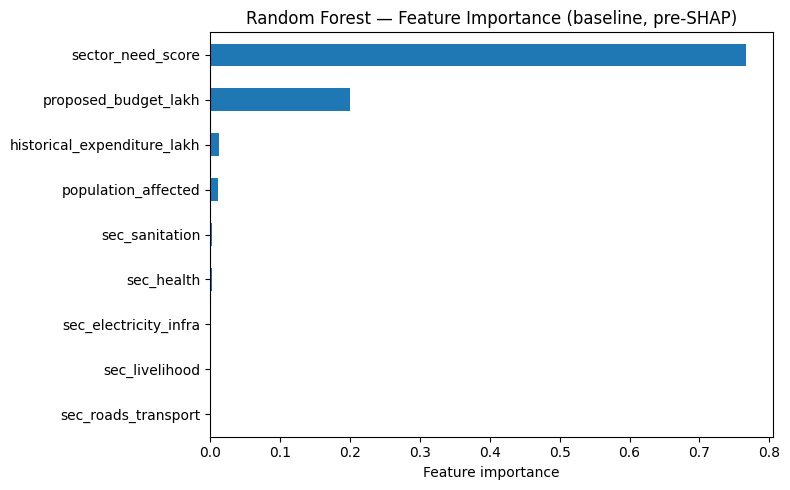

Saved: /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/phase2_feature_importance.png


In [ ]:
importances = pd.Series(
    trained_models["Random Forest"].feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print(importances)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Feature importance")
plt.title("Random Forest — Feature Importance (baseline, pre-SHAP)")
plt.tight_layout()

chart_file = os.path.join(CLEAN_DIR, "phase2_feature_importance.png")
plt.savefig(chart_file, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", chart_file)


## 7. Handoff notes — what's done, what's synthetic, what's next

**Done in this notebook (safe to present as pipeline validation):**
- End-to-end Phase 2 skeleton runs: data → features → 3 trained regressors → metrics table → saved outputs.
- All four files below are written to `Cleaned/` and ready to commit to GitHub:
  - `synthetic_project_impact_dataset.csv`
  - `phase2_model_performance.csv`
  - `phase2_feature_importance.png`

**Flagged as synthetic/proxy — do not present as findings:**
- `synthetic_impact` (the target variable) is a formula, not an observed outcome.
- `sector_need_score` is the overall Need Score with jitter, not a true sector-specific `N_is`.

**Suggested next steps, roughly in priority order:**
1. **Compute real per-sector Need Scores.** Go back to Phase 1's `normalized_df` / `final_candidates`, group indicators by sector (e.g. road indicators → roads `N_is`, health indicator → health `N_is`), and re-weight within each sector. Swap this into `sector_need_score` here.
2. **Source real project/expenditure data if possible** — even partial (e.g. this year's XVFC fund utilization by sector) would let `historical_expenditure_lakh` become real instead of random, and could seed a small real target variable.
3. **Hyperparameter tuning** for all three models (grid/random search or Optuna) — current run uses default-ish settings (`n_estimators=200`) as a baseline only.
4. **Time-aware validation** if multi-year data becomes available, per the document's note on panel-data validation to avoid leakage.
5. **SHAP explainability** (Phase 4) — once a model is tuned and real (or better-justified synthetic) data is used, add `shap.TreeExplainer` for both model-level and instance-level explanations.
6. **Feed into Phase 3** — the trained model's `.predict()` becomes the `I_{i,s}(a_{i,s})` term the PSO/NSGA-II optimizer needs; the saved model objects in `trained_models` are ready to be pickled for that handoff.

**One paragraph for your status narrative:**
> *"Phase 1 (data preparation and Entropy-weighted Need Scoring) is complete for all 33 Devadurga GPs. Phase 2 has a validated end-to-end pipeline (Random Forest, XGBoost, and LightGBM baselines, all under MAE 0.06 / R² above 0.83 on synthetic data), built on a clearly documented synthetic project-impact dataset pending real project-outcome data. Next steps are computing true sector-level Need Scores, sourcing real expenditure data, and hyperparameter tuning before Phase 3 optimization and Phase 4 SHAP explainability."*
